# Portuguese Bank Marketing Campaign Analysis & Prediction

# Project Overview

This project analyzes a Portuguese bank's direct marketing campaign data to understand customer characteristics and identify customers who are likely to subscribe to a term deposit. The analysis combines Exploratory Data Analysis (EDA), data preprocessing, feature engineering, and multiple machine learning classification algorithms to develop a predictive solution for the bank's marketing team.

The project focuses on identifying important customer and campaign characteristics associated with term-deposit subscriptions, comparing the performance of multiple classification models, and selecting the most suitable model for potential production use. The analysis also provides data-driven recommendations to help the bank improve customer targeting and marketing campaign effectiveness.

The dataset contains 41,188 customer records and 21 variables, covering demographic information, financial characteristics, contact details, campaign history, and the target variable indicating whether the customer subscribed to a term deposit.

# Project Objectives
- Perform comprehensive data cleaning and exploratory analysis.
- Understand customer demographics, financial characteristics, and campaign behavior.
- Identify factors associated with term-deposit subscription.
- Perform univariate, bivariate, and multivariate analysis.
- Analyze and handle potential outliers appropriately.
- Prepare the dataset for machine learning through preprocessing and feature engineering.
- Develop multiple classification models to predict customer subscription.
- Compare model performance using appropriate evaluation metrics.
- Select the most suitable model for production.
- Provide actionable recommendations to the bank's marketing team.
- Document challenges encountered and the techniques used to address them.

# Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

df.shape

(41188, 21)

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.shape

(41188, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Data Cleaning

In [12]:
missing = df.isnull().sum()
missing

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [13]:
df.duplicated().sum()

12

In [14]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

# EDA

## 1. Target Variable Distribution

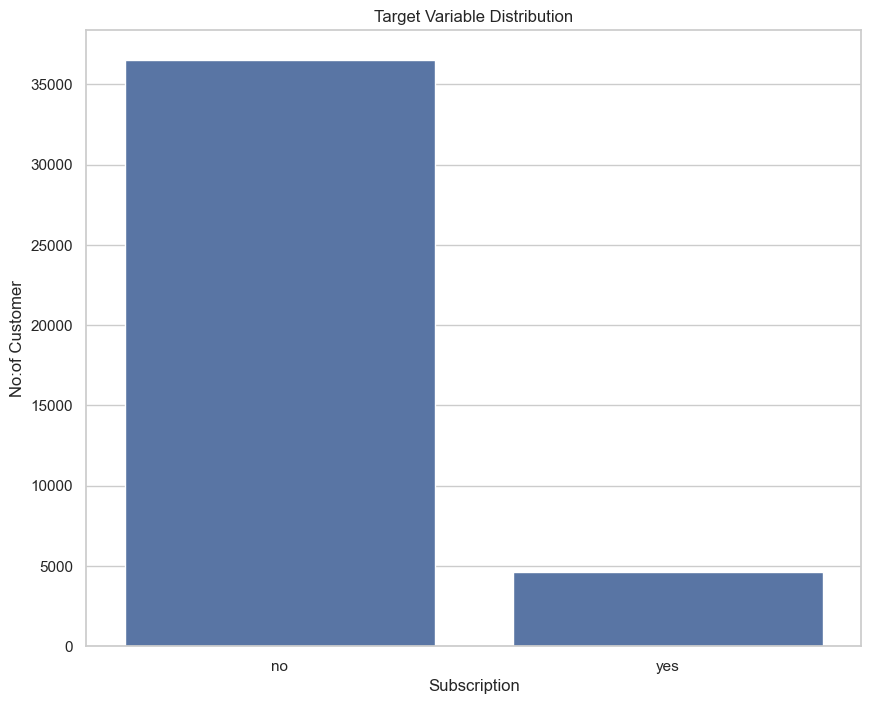

In [17]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x="y")

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("No:of Customer")

plt.show()

In [18]:
target_pct = df["y"].value_counts(normalize=True) * 100
target_pct.round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

The target variable is highly imbalanced. Approximately 88% of customers did not subscribe to the term deposit, while only around 12% subscribed. This indicates that identifying potential subscribers will be more challenging than predicting non-subscribers. Therefore, model evaluation will focus not only on accuracy but also on precision, recall, F1-score, ROC-AUC, and the confusion matrix.

## 2. Numerical Variable Analysis

In [21]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

### Age Distribution

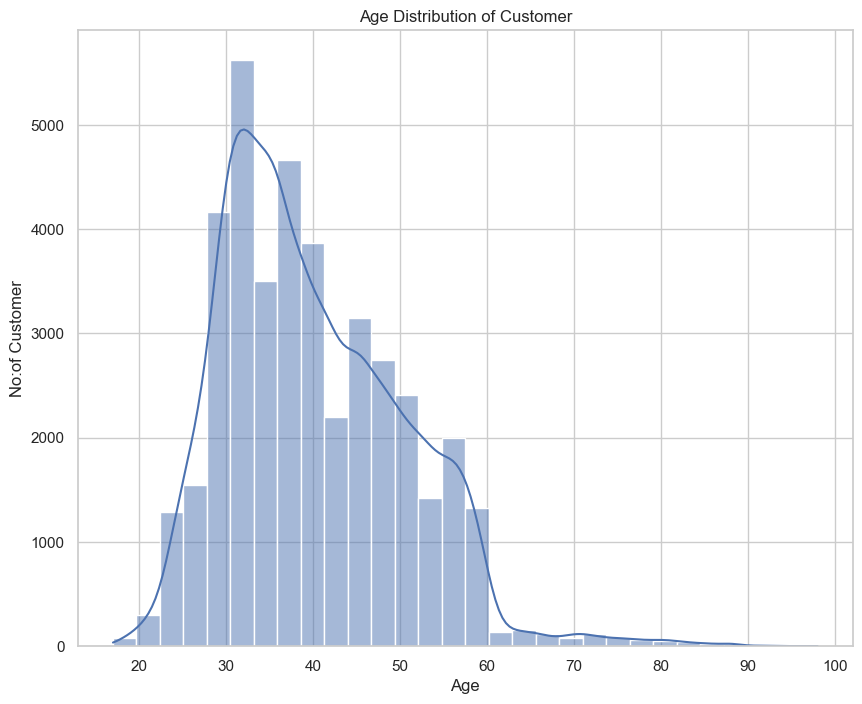

In [23]:
plt.figure(figsize=(10,8))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution of Customer")
plt.xlabel("Age")
plt.ylabel("No:of Customer")

plt.show()

The customer base covers a wide range of age groups, with the distribution concentrated around middle-aged customers. The presence of younger and older customers provides an opportunity to investigate whether age is associated with term-deposit subscription.

### Campaign Contacts Distribution

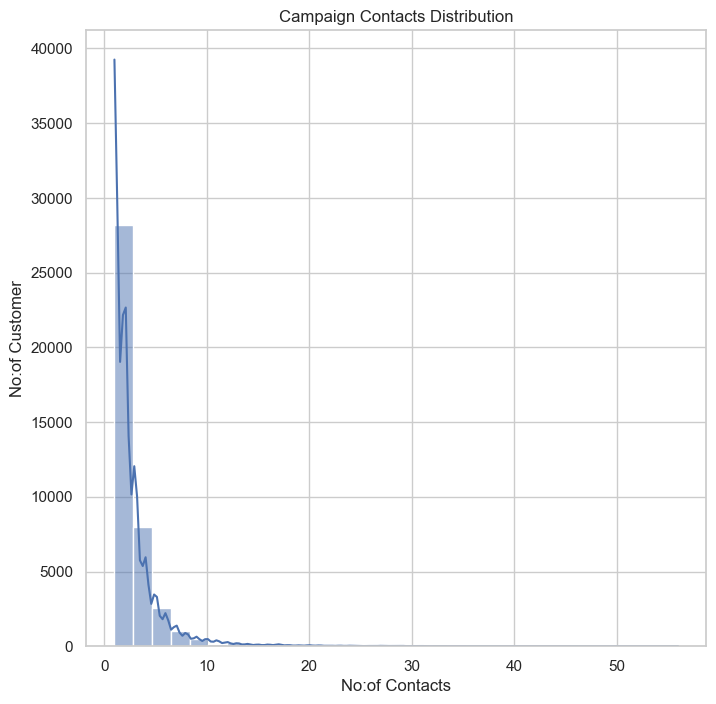

In [26]:
plt.figure(figsize=(8,8))

sns.histplot(data=df, x="campaign", bins=30, kde=True)

plt.title("Campaign Contacts Distribution")
plt.xlabel("No:of Contacts")
plt.ylabel("No:of Customer")

plt.show()

Most customers were contacted a relatively small number of times during the campaign, while a smaller group received considerably more contacts. This variable may provide useful information about the relationship between repeated contacts and subscription outcomes.

### Previous Campaign Contacts

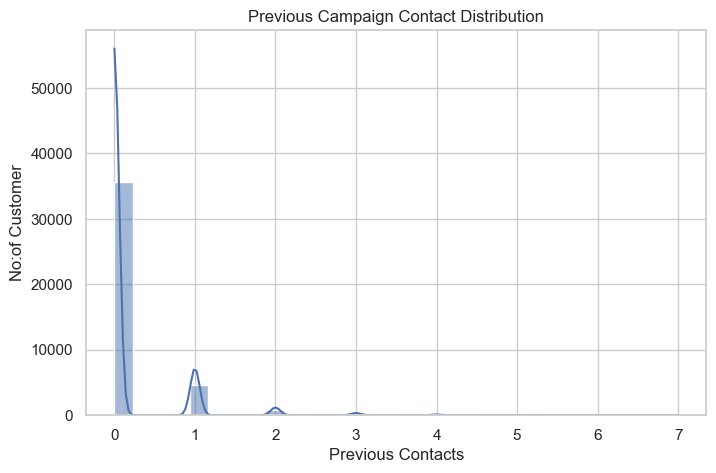

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="previous", bins=30, kde=True)

plt.title("Previous Campaign Contact Distribution")
plt.xlabel("Previous Contacts")
plt.ylabel("No:of Customer")

plt.show()

Most customers had few or no previous contacts before the current campaign. Customers with previous campaign interactions may have different subscription behavior, making this variable relevant for further bivariate analysis.

## 3. Economic Variable Analysis

In [32]:
economic_cols = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

economic_summary = (
    df.groupby("y")[economic_cols]
    .mean()
    .T
    .round(3)
)

economic_summary

y,no,yes
emp.var.rate,0.249,-1.233
cons.price.idx,93.604,93.354
cons.conf.idx,-40.593,-39.790
euribor3m,3.811,2.123
nr.employed,5176.167,5095.116


### Economic Variables – Interpretation

The economic indicators show differences between customers who subscribed and those who did not. These variables capture the broader economic environment during the marketing campaign and may provide additional predictive information when combined with customer and campaign characteristics.

## 4. Categorical Variable Analysis

### Customer Job Distribution

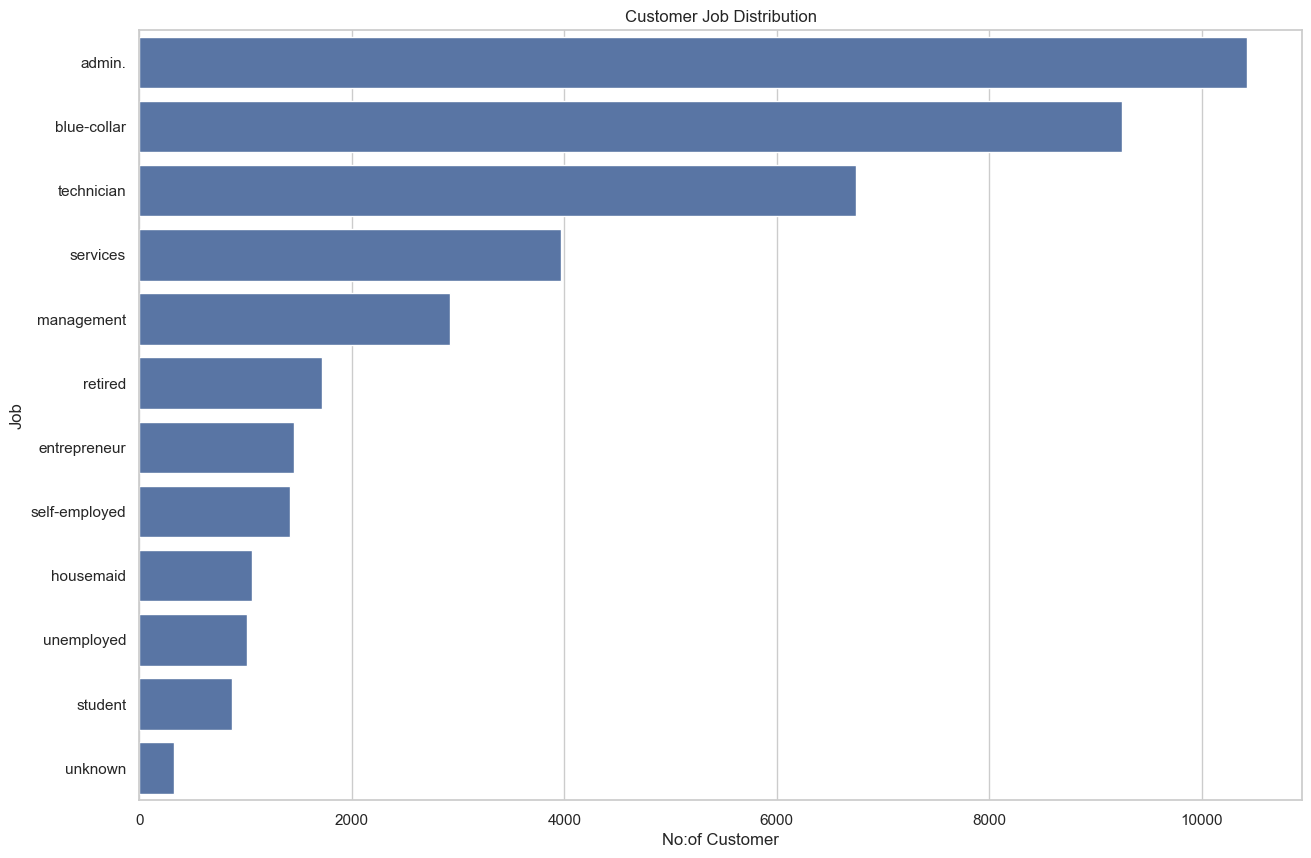

In [36]:
plt.figure(figsize=(15,10))

sns.countplot(data=df, y="job", order=df['job'].value_counts().index)

plt.title("Customer Job Distribution")
plt.ylabel("Job")
plt.xlabel("No:of Customer")

plt.show()

The customer base consists of customers from diverse occupational groups. Management, blue-collar, and technician-related occupations represent substantial portions of the dataset, while some occupations have comparatively fewer customers. Job type will be further analyzed against subscription status to identify differences in campaign response.

### Customer Distribution by Education

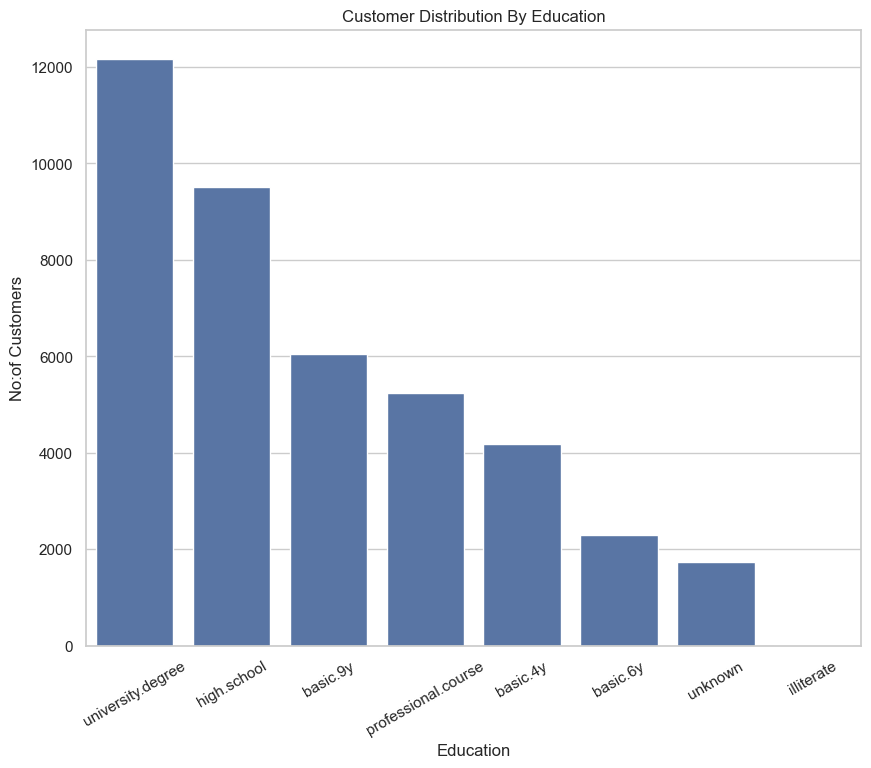

In [39]:
plt.figure(figsize=(10,8))

sns.countplot(data=df, x="education", order=df['education'].value_counts().index
             )

plt.title("Customer Distribution By Education")
plt.xlabel("Education")
plt.ylabel("No:of Customers")

plt.xticks(rotation=30)
plt.show()

Secondary education represents the largest share of customers, followed by tertiary and primary education. The unknown category represents a relatively small portion of the dataset. Education level will be further analyzed against subscription status to determine whether it influences term-deposit acceptance.

### Customer Distribution by Marital Status

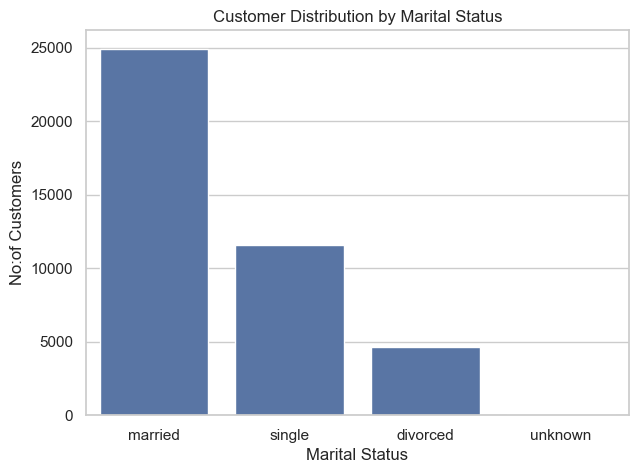

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="marital")

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("No:of Customers")

plt.show()

Married customers form the largest marital-status group, followed by single and divorced customers. The relationship between marital status and subscription will be examined in the bivariate analysis.

### Customer Distribution by Housing Loan

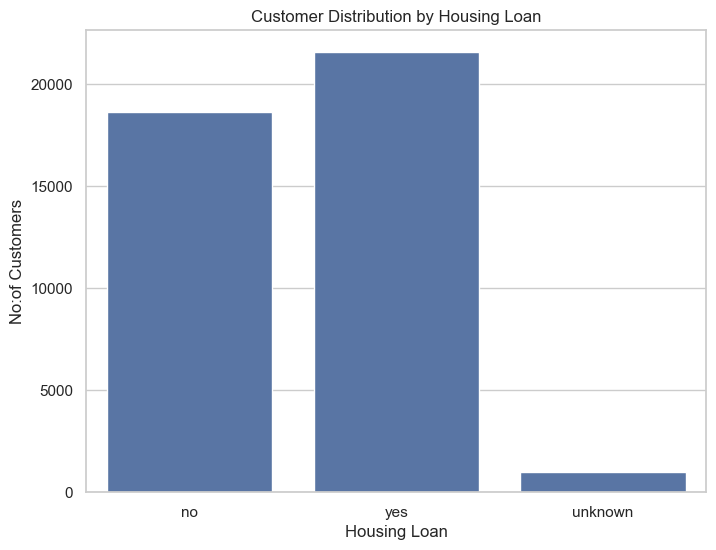

In [45]:
plt.figure(figsize=(8,6))

sns.countplot(data=df, x="housing")

plt.title("Customer Distribution by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("No:of Customers")

plt.show()

### Customer Distribution by Personal Loans

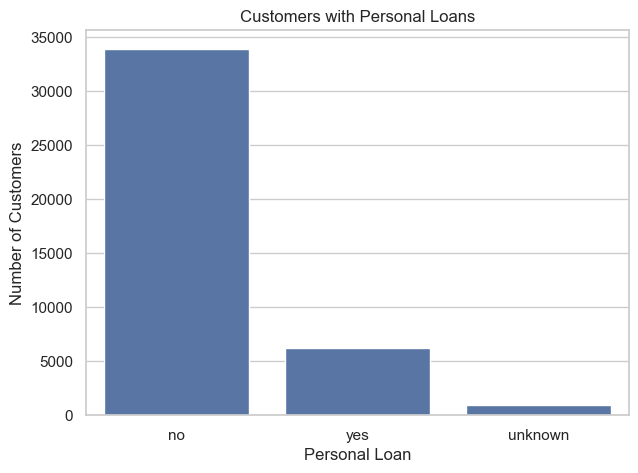

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="loan")

plt.title("Customers with Personal Loans")
plt.xlabel("Personal Loan")
plt.ylabel("Number of Customers")

plt.show()

## Bivarient Analysis

### Age vs Subscription

In [50]:
age_subscription = (
    df.groupby("y")['age']
    .mean()
    .round(2)
)
age_subscription



y
no     39.91
yes    40.91
Name: age, dtype: float64

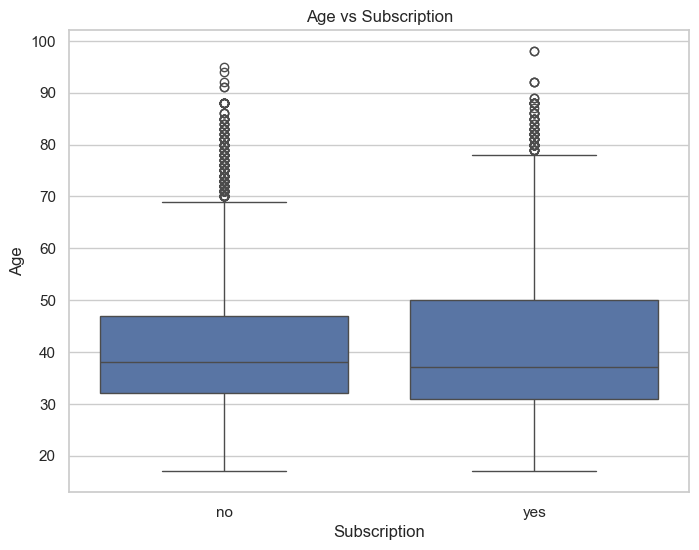

In [51]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="y", y="age")

plt.title("Age vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Age")

plt.show()

The average age of customers who subscribed is approximately 41.67 years, compared with 40.84 years for non-subscribers. The boxplot also shows substantial overlap between the two groups, indicating that age alone does not strongly distinguish subscribers from non-subscribers. However, subscribers show a slightly wider age distribution, suggesting that subscription interest exists across a broader range of ages

### Job vs Subscription

In [54]:
job_subscription = (
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    ) * 100
)

job_subscription

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


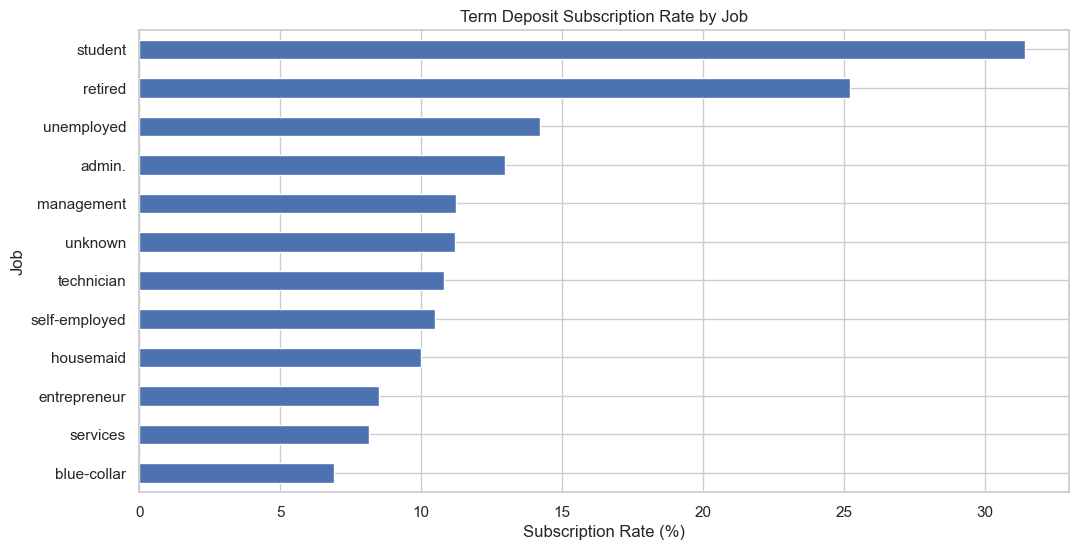

In [55]:
plt.figure(figsize=(12,6))

job_subscription["yes"].sort_values().plot(
    kind="barh"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.show()

Subscription rates vary considerably across occupational groups. Students have the highest subscription rate at approximately 28.68%, followed by retired customers at 22.79% and unemployed customers at 15.50%. In contrast, blue-collar customers have one of the lowest subscription rates at approximately 7.27%. This indicates that occupation could be an important factor for customer targeting.

### Education vs Subscription

In [58]:
education_subscription = (
    pd.crosstab(
        df["education"],
        df["y"],
        normalize="index"
    ) * 100
)

education_subscription

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648
high.school,89.164477,10.835523
illiterate,77.777778,22.222222
professional.course,88.651535,11.348465
university.degree,86.275477,13.724523
unknown,85.499711,14.500289


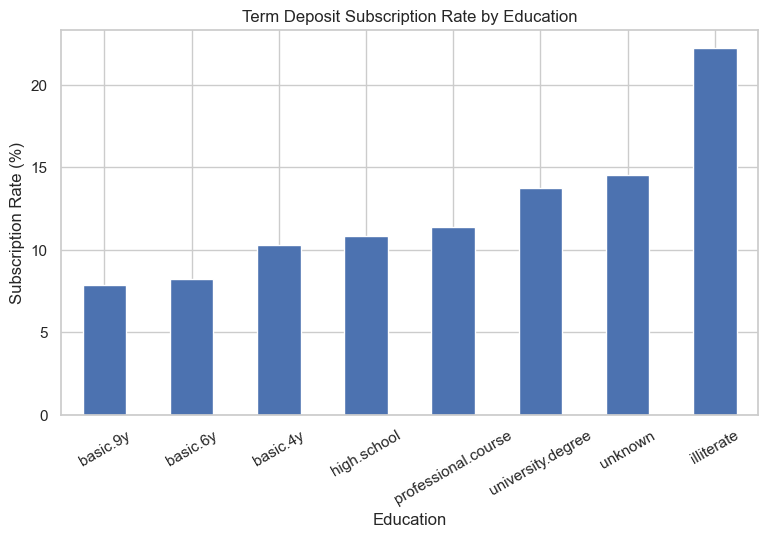

In [59]:
plt.figure(figsize=(9,5))

education_subscription["yes"].sort_values().plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=30)

plt.show()

Customers with tertiary education have the highest subscription rate at approximately 15.01%, followed by customers with unknown education levels at 13.57%. Secondary and primary education groups have lower subscription rates of approximately 10.56% and 8.63%, respectively. This suggests a moderate relationship between education level and term-deposit subscription.

### Marital Status vs Subscription

In [62]:
marital_subscription = (
    pd.crosstab(
        df["marital"],
        df["y"],
        normalize="index"
    ) * 100
)

marital_subscription

y,no,yes
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


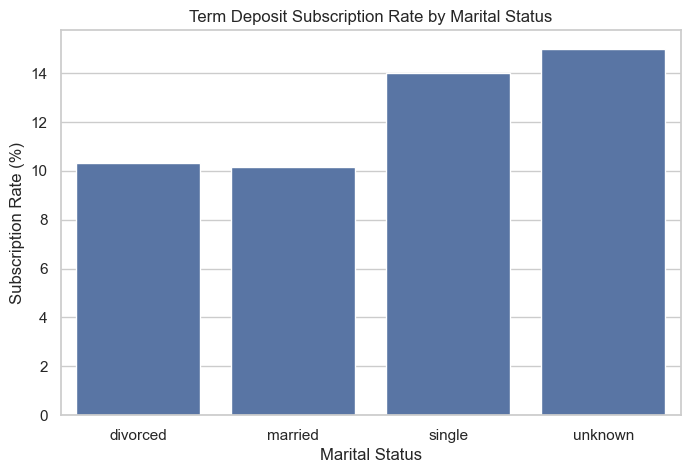

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=marital_subscription.index,
    y=marital_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")

plt.show()

Single customers have the highest subscription rate at approximately 14.95%, followed by divorced customers at 11.95%. Married customers have the lowest subscription rate at approximately 10.12%. This indicates that marital status may have some influence on campaign response, with single customers showing greater interest in the term-deposit offering.

### Housing Loan vs Subscription

In [66]:
housing_subscription = (
    pd.crosstab(
        df["housing"],
        df["y"],
        normalize="index"
    ) * 100
)

housing_subscription

y,no,yes
housing,,
no,89.120395,10.879605
unknown,89.191919,10.808081
yes,88.380608,11.619392


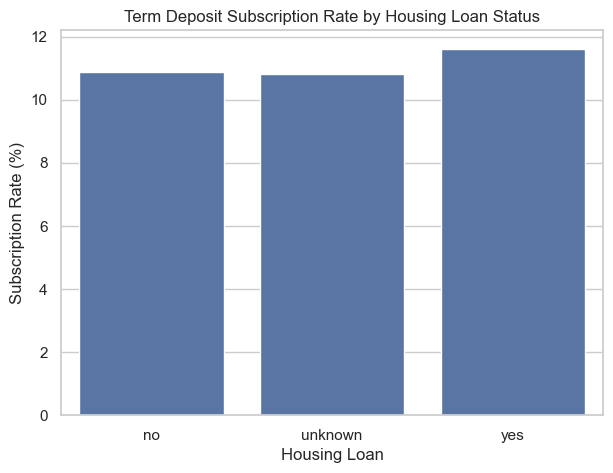

In [67]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=housing_subscription.index,
    y=housing_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")

plt.show()

Customers without a housing loan have a substantially higher subscription rate (16.70%) compared with customers who have a housing loan (7.70%). This represents a significant difference and suggests that existing housing-loan commitments may be associated with a lower likelihood of subscribing to a term deposit.

### Personal Loan vs Subscription

In [70]:
loan_subscription = (
    pd.crosstab(
        df["loan"],
        df["y"],
        normalize="index"
    ) * 100
)

loan_subscription

y,no,yes
loan,,
no,88.659794,11.340206
unknown,89.191919,10.808081
yes,89.068502,10.931498


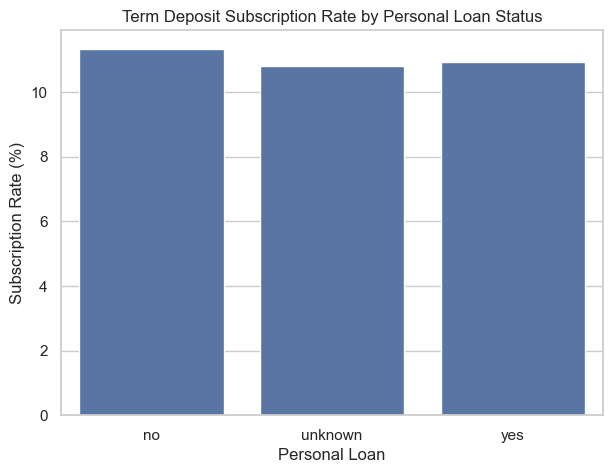

In [71]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=loan_subscription.index,
    y=loan_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")

plt.show()

Customers without a personal loan have a subscription rate of approximately 12.66%, compared with only 6.68% among customers with a personal loan. Customers without personal-loan commitments therefore appear considerably more likely to subscribe, suggesting that existing financial commitments may influence their willingness to invest in a term deposit.

### Contact Method vs Subscription

In [74]:
contact_subscription = (
    pd.crosstab(
        df["contact"],
        df["y"],
        normalize="index"
    ) * 100
)

contact_subscription

y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


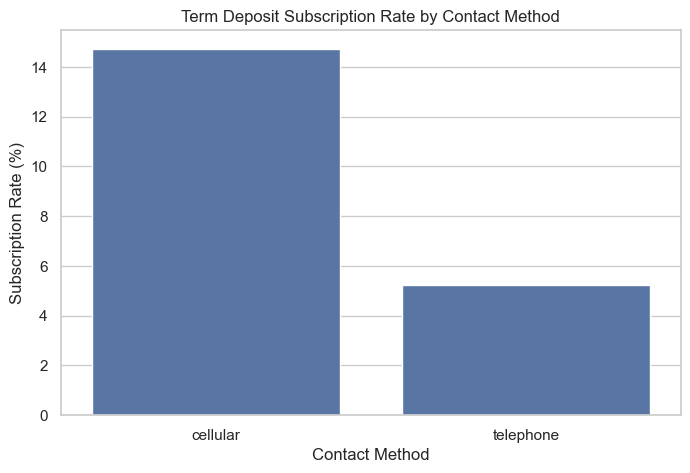

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=contact_subscription.index,
    y=contact_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

plt.show()

Customers contacted through cellular communication have the highest subscription rate at approximately 14.92%, followed by telephone at 13.42%. Customers with an unknown contact method have a substantially lower subscription rate of only 4.07%. This suggests that the method and availability of customer contact may influence campaign effectiveness.

### Campaign Contacts vs Subscription

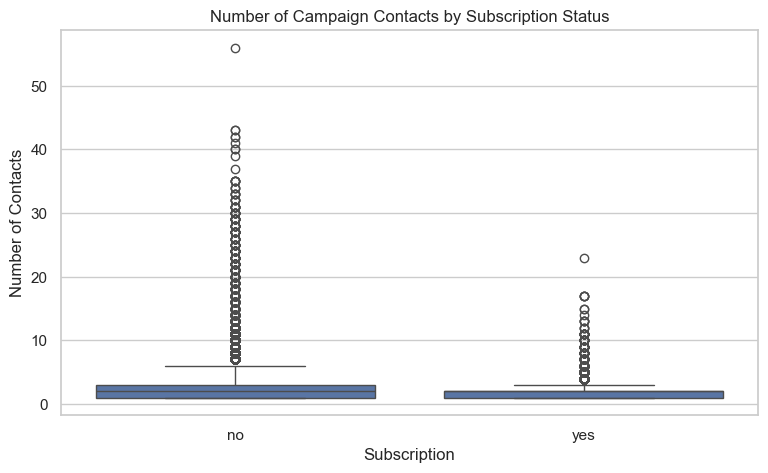

In [78]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="y",
    y="campaign"
)

plt.title("Number of Campaign Contacts by Subscription Status")
plt.xlabel("Subscription")
plt.ylabel("Number of Contacts")

plt.show()

The number of contacts during the current campaign shows a tendency toward fewer contacts among successful subscriptions, while customers who did not subscribe include more observations with repeated contacts. This suggests that repeatedly contacting the same customer may not necessarily improve conversion and could potentially indicate diminishing campaign effectiveness.

### Previous Campaign Outcome

In [81]:
poutcome_subscription = (
    pd.crosstab(
        df["poutcome"],
        df["y"],
        normalize="index"
    ) * 100
)

poutcome_subscription

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


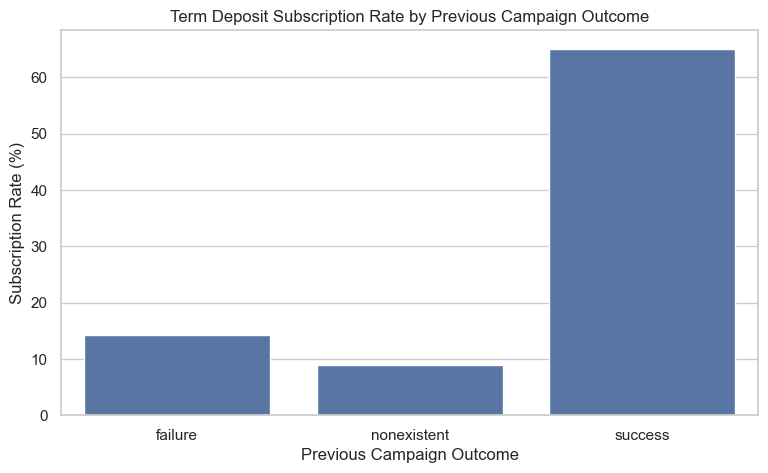

In [82]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=poutcome_subscription.index,
    y=poutcome_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()

Previous campaign outcome shows one of the strongest relationships with the current subscription decision. Customers with a successful previous campaign outcome have a subscription rate of approximately 64.73%, dramatically higher than customers with unknown (9.16%) or failed previous outcomes (12.61%). This indicates that previous positive campaign responses are a particularly strong indicator for identifying customers who may be receptive to future marketing campaigns.

### Month vs Subscription

In [85]:
month_subscription = (
    pd.crosstab(
        df["month"],
        df["y"],
        normalize="index"
    ) * 100
)

month_subscription

y,no,yes
month,,
apr,79.521277,20.478723
aug,89.397863,10.602137
dec,51.098901,48.901099
jul,90.953443,9.046557
jun,89.488530,10.511470
mar,49.450549,50.549451
may,93.565255,6.434745
nov,89.856133,10.143867
oct,56.128134,43.871866


In [86]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_subscription = month_subscription.reindex(month_order)

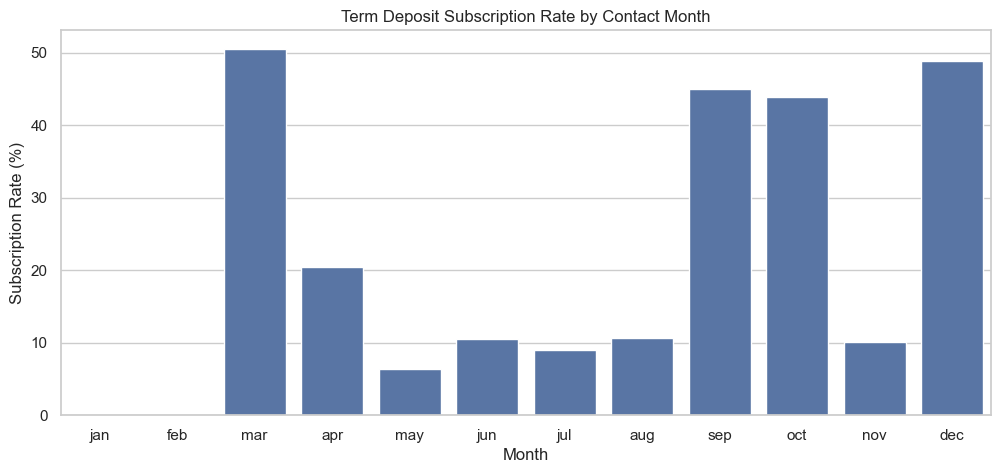

In [87]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=month_subscription.index,
    y=month_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.show()

Subscription rates vary substantially across contact months. March has the highest subscription rate at approximately 51.99%, followed by December (46.73%), October (43.77%), and September (46.46%). In contrast, May has the lowest subscription rate at approximately 6.72%. This indicates that campaign timing may have a significant relationship with customer response and could be useful for optimizing future marketing campaigns.

### Day of Week vs Subscription

In [90]:
day_order = ["mon", "tue", "wed", "thu", "fri"]

day_subscription = (
    pd.crosstab(
        df["day_of_week"],
        df["y"],
        normalize="index"
    ) * 100
)

day_subscription = day_subscription.reindex(day_order)

day_subscription.round(2)

y,no,yes
day_of_week,,
mon,90.05,9.95
tue,88.22,11.78
wed,88.33,11.67
thu,87.88,12.12
fri,89.19,10.81


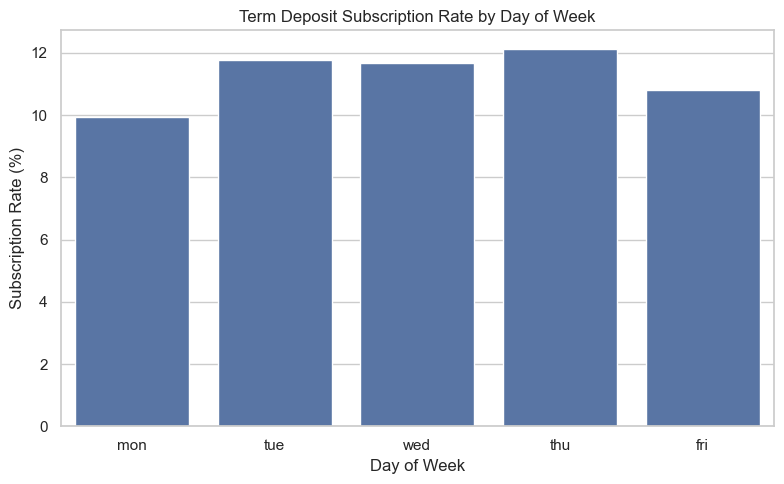

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=day_subscription.index,
    y=day_subscription["yes"].values
)

plt.title("Term Deposit Subscription Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.show()

Subscription rates vary slightly across the days of the week. Thursday shows the highest subscription rate, while Monday has the lowest. However, the differences are relatively small, suggesting that day of the week alone may not be a strong predictor of subscription behaviour. Therefore, day of week should be considered alongside other customer and campaign characteristics when planning marketing campaigns.

## Key Bivariate Insights
- Previous campaign success is the strongest apparent indicator, with a 64.73% subscription rate.
- Students and retired customers show considerably higher subscription rates than several other occupational groups.
- Customers without housing or personal loans are more likely to subscribe.
- Single customers show a higher subscription rate than married customers.
- Tertiary-educated customers have a higher subscription rate than primary and secondary groups.
- Cellular contact performs better than unknown contact methods.
- Subscription rates vary substantially by campaign month, suggesting that campaign timing may be important.
- Age show considerable overlap between subscribers and non-subscribers, suggesting that they may be more useful when combined with other characteristics rather than used independently.

## Multivariate Analysis

Multivariate analysis is used to examine relationships among multiple variables simultaneously and identify patterns that may not be visible through individual variable comparisons. In this section, numerical relationships and interactions between customer characteristics will be explored to better understand factors associated with term-deposit subscription.

### Correlation Heatmap

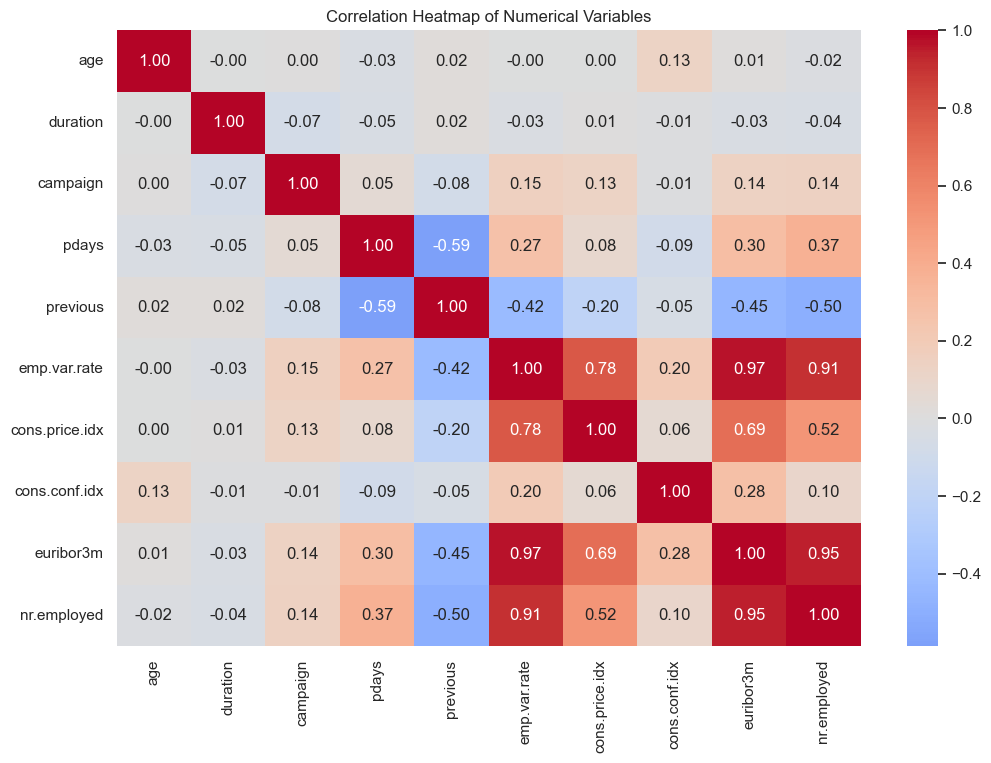

In [96]:
numeric_cols = df.select_dtypes(include=np.number).columns

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Correlation Analysis – Interpretation

The correlation analysis shows varying degrees of association among the numerical variables. Some campaign and economic variables show stronger relationships because they describe related aspects of the same campaign or economic environment.

The correlation matrix is primarily used to understand relationships among numerical features and identify potentially redundant variables. However, correlation alone does not determine whether a variable is useful for prediction.

## Outlier Analysis

Outlier analysis is performed to identify unusually high or low observations in the numerical variables. The presence of an outlier does not necessarily indicate an incorrect record, as extreme values may represent genuine customer characteristics or unusual campaign interaction patterns.

Therefore, potential outliers are identified using the IQR method and evaluated according to their statistical and business context before deciding whether treatment is necessary.

In [99]:
numerical_cols = [
    "age",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

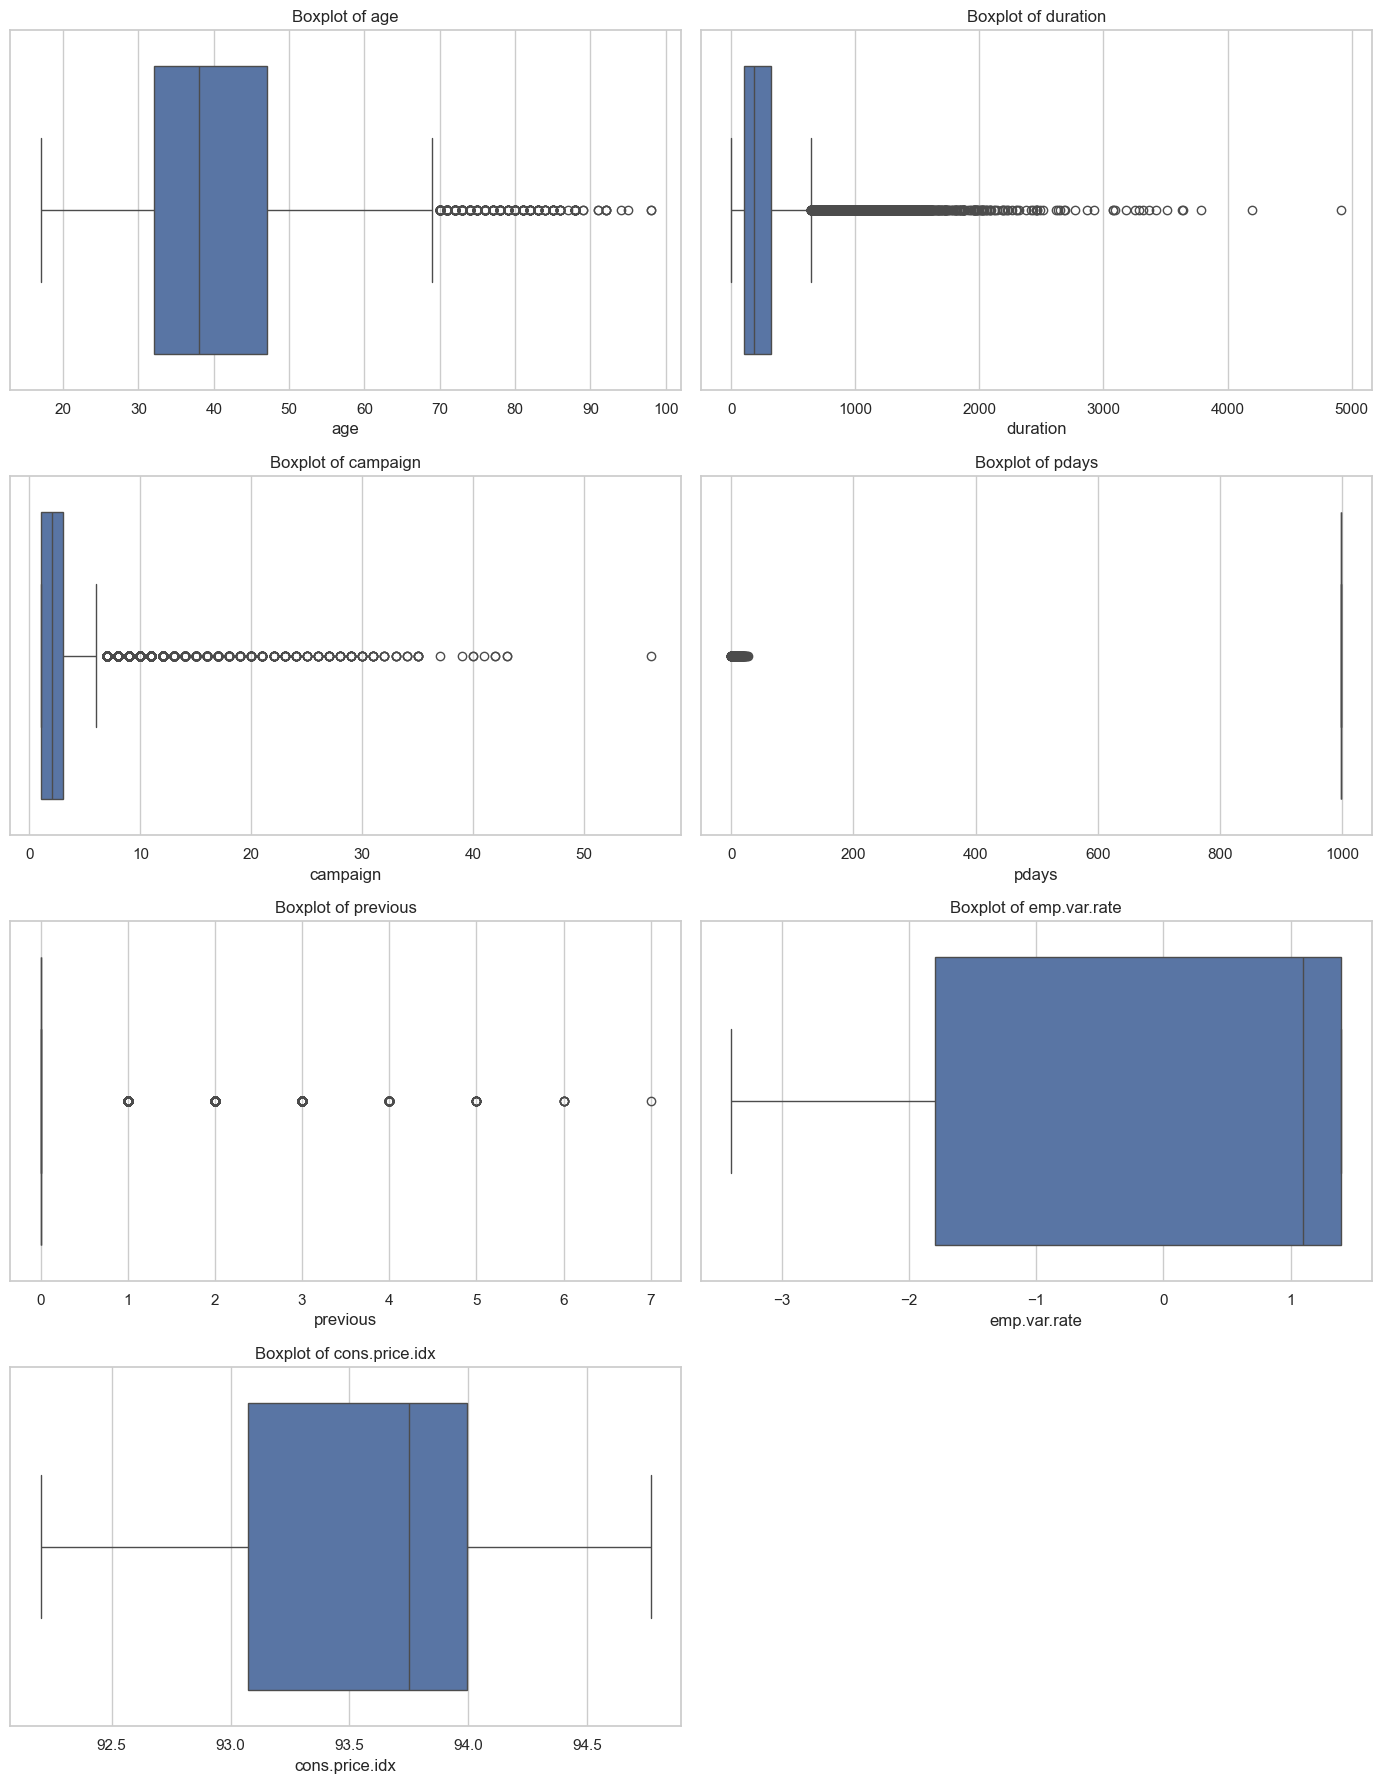

In [100]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=ax
    )
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

# Remove unused subplot
axes.flatten()[-1].remove()

plt.tight_layout()
plt.show()

In [101]:
outlier_summary = []

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,age,32.000,47.000,15.000,9.5000,69.5000,469,1.14
1,duration,102.000,319.000,217.000,-223.5000,644.5000,2963,7.19
2,campaign,1.000,3.000,2.000,-2.0000,6.0000,2406,5.84
3,pdays,999.000,999.000,0.000,999.0000,999.0000,1515,3.68
4,previous,0.000,0.000,0.000,0.0000,0.0000,5625,13.66
5,emp.var.rate,-1.800,1.400,3.200,-6.6000,6.2000,0,0.00
6,cons.price.idx,93.075,93.994,0.919,91.6965,95.3725,0,0.00
7,cons.conf.idx,-42.700,-36.400,6.300,-52.1500,-26.9500,447,1.09
8,euribor3m,1.344,4.961,3.617,-4.0815,10.3865,0,0.00
9,nr.employed,5099.100,5228.100,129.000,4905.6000,5421.6000,0,0.00


In [102]:
outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
4,previous,0.000,0.000,0.000,0.0000,0.0000,5625,13.66
1,duration,102.000,319.000,217.000,-223.5000,644.5000,2963,7.19
2,campaign,1.000,3.000,2.000,-2.0000,6.0000,2406,5.84
3,pdays,999.000,999.000,0.000,999.0000,999.0000,1515,3.68
0,age,32.000,47.000,15.000,9.5000,69.5000,469,1.14
7,cons.conf.idx,-42.700,-36.400,6.300,-52.1500,-26.9500,447,1.09
5,emp.var.rate,-1.800,1.400,3.200,-6.6000,6.2000,0,0.00
6,cons.price.idx,93.075,93.994,0.919,91.6965,95.3725,0,0.00
8,euribor3m,1.344,4.961,3.617,-4.0815,10.3865,0,0.00
9,nr.employed,5099.100,5228.100,129.000,4905.6000,5421.6000,0,0.00


### Outlier Analysis Findings

The IQR method identified potential extreme observations across several numerical variables. However, these observations were interpreted in the context of the dataset rather than automatically treated as errors.

Variables such as `campaign`, `pdays`, and `previous` require particular care because their distributions contain values that represent specific customer or campaign situations rather than conventional statistical outliers.

For example, `pdays = 999` represents customers who were not previously contacted. Therefore, these observations should not be removed simply because they fall outside an IQR-based range.

Similarly, extreme values in campaign-related variables may represent genuine customer interaction patterns.

Therefore, the identified observations were retained rather than automatically removed.

## EDA Summary and Key Insights

### Key Findings from Exploratory Data Analysis

The exploratory analysis provided several important insights into customer characteristics and term-deposit subscription behavior.

- The dataset contains **41,188** customers and 21 variables, with a clear class imbalance between subscribers and non-subscribers.
- Subscription behavior varies considerably across **occupational groups**, with students and retired customers showing comparatively higher subscription rates.
- Customers with **tertiary education** demonstrate a higher subscription rate compared with customers with primary or secondary education.
- **Single customers** show a higher subscription rate than married customers.
- Customers **without housing loans and personal loans** are more likely to subscribe to the term deposit.
- Customers contacted through **cellular communication** show stronger subscription rates than customers with unknown contact methods.
- **Previous campaign outcome** is one of the strongest indicators of current subscription behavior. Customers who responded positively to a previous campaign have a substantially higher likelihood of subscribing.
- Subscription rates vary significantly across **contact months**, indicating that campaign timing may influence customer response.
- Age shows considerable overlap between subscribers and non-subscribers, suggesting that age alone is not a strong discriminator.
- The analysis of `pdays` and `previous` demonstrates the importance of understanding the **business meaning of encoded values** before treating statistically unusual observations as errors.

### Business Implications

The exploratory analysis suggests that the bank can improve campaign targeting by prioritizing customer segments that demonstrate higher historical subscription rates. Previous campaign success appears particularly valuable for identifying receptive customers. Customer characteristics such as occupation, education, loan status and contact method can further support segmentation.

The findings also indicate that campaign effectiveness may depend on both the timing and method of customer contact. Rather than contacting customers repeatedly without differentiation, the bank could prioritize customers based on their previous campaign response and relevant customer characteristics.

These findings will be further evaluated through predictive modeling to identify the factors that most strongly contribute to term-deposit subscription.

## Data Preprocessing

Data preprocessing prepares the dataset for machine learning by selecting relevant features, encoding categorical variables, handling the target variable, and ensuring that the data is suitable for model training. The preprocessing steps are designed to avoid data leakage and preserve meaningful customer information.

In [109]:
X = df.drop("y", axis=1).copy()
y = df["y"].map({"no": 0, "yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41188, 20)
y shape: (41188,)


In [110]:
X = X.drop(
    columns=["duration"],
    errors="ignore"
)

print("Features after excluding duration:", X.shape)

Features after excluding duration: (41188, 19)


### Feature Exclusion

The duration feature is excluded from predictive modeling because it represents the duration of the current marketing call and is only known after the customer interaction. Using this variable would introduce data leakage and would not reflect a realistic pre-campaign prediction scenario.

In [112]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [113]:
X.select_dtypes(include="object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (32950, 19)
X_test : (8238, 19)
y_train: (32950,)
y_test : (8238,)


In [115]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Testing target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


In [116]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (32950, 62)
Processed testing shape: (8238, 62)


In [118]:
print(
    "Training mean:",
    X_train_processed.mean().round(4)
)

print(
    "Training standard deviation:",
    X_train_processed.std().round(4)
)

Training mean: 0.1613
Training standard deviation: 0.5296


In [119]:
scaled_numeric = X_train_processed[:, :len(numerical_features)]

print("Numerical feature means:")
print(np.mean(scaled_numeric, axis=0).round(4))

print("\nNumerical feature standard deviations:")
print(np.std(scaled_numeric, axis=0).round(4))

Numerical feature means:
[ 0. -0. -0. -0. -0.  0. -0. -0.  0.]

Numerical feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [120]:
print("Training target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(4))

Training target distribution:
y
0    29238
1     3712
Name: count, dtype: int64
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64

Testing target distribution:
y
0    7310
1     928
Name: count, dtype: int64
y
0    0.8874
1    0.1126
Name: proportion, dtype: float64


# Machine Learning Model Development

## 1. Logistic Regression – Baseline Model

Logistic Regression is used as the baseline classification model because it is simple, interpretable, computationally efficient, and well suited for binary classification. It provides a useful benchmark against which more complex classification algorithms can be compared.

Since the target variable is imbalanced, class weights are incorporated to give greater importance to the minority class (`yes`) during model training.

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [124]:
y_pred_logistic = logistic_model.predict(X_test_processed)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [125]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))
print("ROC-AUC  :", round(roc_auc_logistic, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.835
Precision: 0.3679
Recall   : 0.6466
F1 Score : 0.4689
ROC-AUC  : 0.8009


In [126]:
print(classification_report(
    y_test,
    y_pred_logistic
))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



### Confusion Matrix

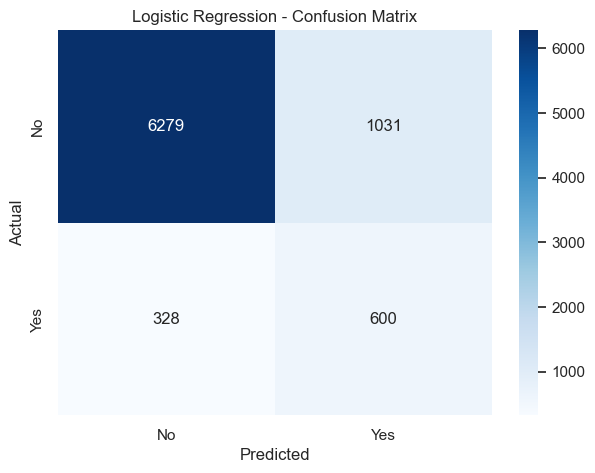

In [128]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression – Interpretation

Logistic Regression achieved an accuracy of **83.50%**, precision of **36.79%**, recall of **64.66%**, F1-score of **46.89%**, and ROC-AUC of **80.09%** at the default classification threshold of 0.50.

The model identifies a relatively high proportion of actual term-deposit subscribers, as indicated by its recall of 64.66%. It also achieves the **highest F1-score among the baseline models**, indicating the best balance between precision and recall.

However, the precision of 36.79% indicates that a considerable proportion of customers predicted as subscribers would not actually subscribe. Therefore, while Logistic Regression provides a strong and interpretable baseline, further model tuning and threshold optimization may improve its suitability for the bank's marketing campaign.

## 2. Decision Tree Classifier

A Decision Tree classifier is implemented as a second model to capture non-linear relationships between customer characteristics and term-deposit subscription. Unlike Logistic Regression, a Decision Tree can model interactions and non-linear decision boundaries without requiring linear assumptions.

Class weighting is applied to address the imbalance in the target variable.

In [131]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=6
)

decision_tree.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [132]:
y_pred_tree = decision_tree.predict(X_test_processed)

y_prob_tree = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

In [133]:
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

precision_tree = precision_score(
    y_test,
    y_pred_tree
)

recall_tree = recall_score(
    y_test,
    y_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_pred_tree
)

roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.8208
Precision: 0.3466
Recall   : 0.667
F1 Score : 0.4562
ROC-AUC  : 0.7902


In [134]:
print(classification_report(
    y_test,
    y_pred_tree
))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.35      0.67      0.46       928

    accuracy                           0.82      8238
   macro avg       0.65      0.75      0.67      8238
weighted avg       0.88      0.82      0.84      8238



### Decision Tree – Interpretation

The Decision Tree achieved an accuracy of **82.08%**, precision of **34.66%**, recall of **66.70%**, F1-score of **45.62%**, and ROC-AUC of **79.02%** at the default classification threshold of 0.50.

The model achieved the **highest recall among the baseline models at 66.70%**, meaning it identified the largest proportion of actual term-deposit subscribers. This can be valuable when the bank's primary objective is to minimize missed potential subscribers.

However, its precision of 34.66% indicates that many customers predicted as subscribers would not actually subscribe. Its ROC-AUC and F1-score are also slightly lower than those of Logistic Regression.

Therefore, the Decision Tree is useful when recall is prioritized, but its overall performance suggests that additional tuning or alternative models may provide a better balance between identifying subscribers and reducing unnecessary marketing contacts.

## 3. Random Forest Classifier

Random Forest is used to improve upon the limitations of a single Decision Tree by combining multiple decision trees. This ensemble approach can capture non-linear relationships while generally providing better stability and generalization.

Class weighting is applied to address the imbalance in the target variable.

In [137]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [138]:
y_pred_rf = random_forest.predict(X_test_processed)

y_prob_rf = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [139]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Performance
-------------------------
Accuracy : 0.8941
Precision: 0.5593
Recall   : 0.2845
F1 Score : 0.3771
ROC-AUC  : 0.7833


In [140]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.56      0.28      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238



### Random Forest – Interpretation

Random Forest achieved an accuracy of **89.41%**, precision of **55.93%**, recall of **28.45%**, F1-score of **37.71%**, and ROC-AUC of **78.33%** at the default classification threshold of 0.50.

The model provides substantially higher accuracy and precision than Logistic Regression and Decision Tree. However, its recall is considerably lower at 28.45%, meaning that the model misses a relatively large proportion of customers who actually subscribe to the term deposit.

The high accuracy should therefore be interpreted carefully because the target variable is imbalanced. A model can achieve high overall accuracy while performing relatively poorly at identifying the minority positive class.

Overall, Random Forest demonstrates strong precision and accuracy but provides a weaker balance between precision and recall than Logistic Regression. Further comparison with Gradient Boosting and threshold optimization is therefore required before selecting the final production model.

## 4. Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially, with each new tree attempting to correct errors made by the previous trees. It can capture complex and non-linear relationships in the data and often performs well on structured tabular datasets.

The model will be evaluated using the same metrics as the previous classifiers to ensure a consistent comparison.

In [143]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train_processed,
    y_train
)

GradientBoostingClassifier(random_state=42)

In [144]:
y_pred_gb = gradient_boosting.predict(
    X_test_processed
)

y_prob_gb = gradient_boosting.predict_proba(
    X_test_processed
)[:, 1]

In [145]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("Accuracy :", round(accuracy_gb, 4))
print("Precision:", round(precision_gb, 4))
print("Recall   :", round(recall_gb, 4))
print("F1 Score :", round(f1_gb, 4))
print("ROC-AUC  :", round(roc_auc_gb, 4))

Gradient Boosting Performance
-----------------------------
Accuracy : 0.9011
Precision: 0.6728
Recall   : 0.2371
F1 Score : 0.3506
ROC-AUC  : 0.8091


In [146]:
print(classification_report(
    y_test,
    y_pred_gb
))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.67      0.24      0.35       928

    accuracy                           0.90      8238
   macro avg       0.79      0.61      0.65      8238
weighted avg       0.88      0.90      0.88      8238



### Gradient Boosting – Interpretation

Gradient Boosting achieved an accuracy of **90.11%**, precision of **67.28%**, recall of **23.71%**, F1-score of **35.06%**, and ROC-AUC of **80.91%** at the default classification threshold of 0.50.

The model achieved the **highest accuracy, precision, and ROC-AUC among the baseline models**. Its ROC-AUC of 80.91% indicates that the model has good ability to distinguish between customers who subscribe to the term deposit and those who do not.

The high precision of 67.28% means that when the model predicts a customer as likely to subscribe, the prediction is correct relatively often. However, the recall of 23.71% is comparatively low, meaning that the model identifies only a smaller proportion of the customers who actually subscribe.

The relatively high accuracy should be interpreted carefully because the target variable is imbalanced. Therefore, accuracy alone should not be used to select the final production model.

Overall, Gradient Boosting is the strongest baseline candidate based on its accuracy, precision and ROC-AUC. However, its low recall and F1-score at the default 0.50 threshold indicate that further hyperparameter tuning and probability-threshold optimization may improve its ability to identify potential subscribers.

## Baseline Model Comparison

Four baseline classification models were trained and evaluated using the same training and testing datasets and the same preprocessing pipeline.

The models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since the target variable is imbalanced, accuracy alone is not sufficient for selecting the best model.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many customers predicted as subscribers actually subscribed.
- **Recall** measures how many actual subscribers were correctly identified.
- **F1-score** provides a balance between precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between subscribers and non-subscribers across different probability thresholds.

The comparison is performed using the default classification threshold of 0.50. Threshold optimization is considered separately after the baseline comparison.

In [149]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_gb
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_gb
    ]
})

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8350,0.3679,0.6466,0.4689,0.8009
1,Decision Tree,0.8208,0.3466,0.6670,0.4562,0.7902
2,Random Forest,0.8941,0.5593,0.2845,0.3771,0.7833
3,Gradient Boosting,0.9011,0.6728,0.2371,0.3506,0.8091


In [150]:
comparison_ranked = model_comparison.copy()

comparison_ranked["F1 Rank"] = (
    comparison_ranked["F1 Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison_ranked["ROC-AUC Rank"] = (
    comparison_ranked["ROC-AUC"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison_ranked["Recall Rank"] = (
    comparison_ranked["Recall"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison_ranked.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,F1 Rank,ROC-AUC Rank,Recall Rank
0,Logistic Regression,0.8350,0.3679,0.6466,0.4689,0.8009,1,2,2
1,Decision Tree,0.8208,0.3466,0.6670,0.4562,0.7902,2,3,1
2,Random Forest,0.8941,0.5593,0.2845,0.3771,0.7833,3,4,3
3,Gradient Boosting,0.9011,0.6728,0.2371,0.3506,0.8091,4,1,4


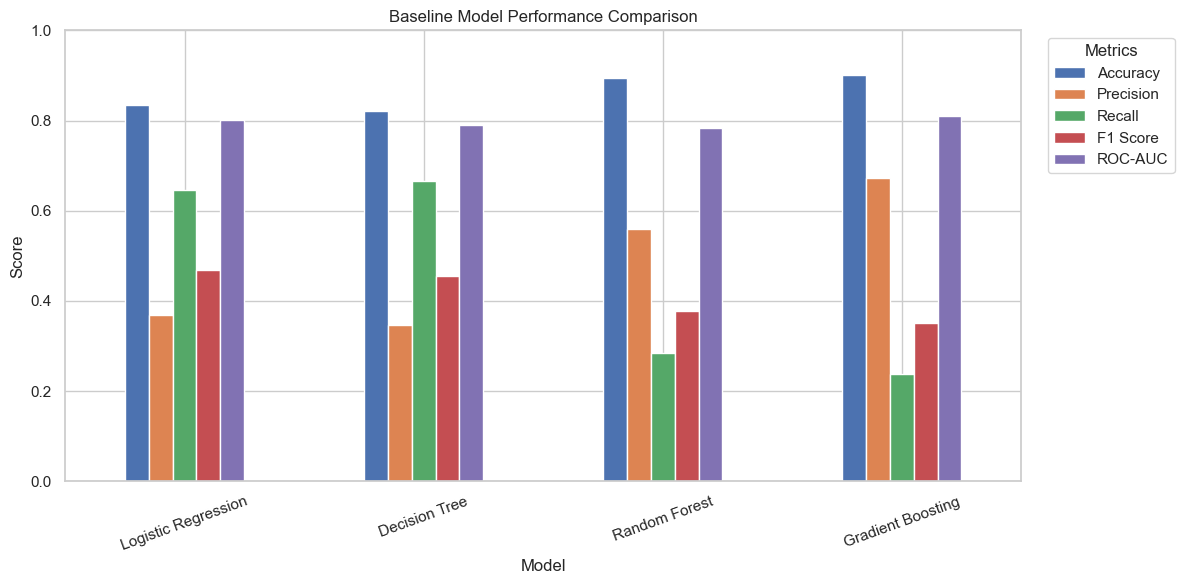

In [151]:
comparison_plot = model_comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Baseline Model Comparison – Key Findings

The baseline models show different strengths depending on the evaluation metric.

**Logistic Regression** achieved an accuracy of 83.50%, precision of 36.79%, recall of 64.66%, F1-score of 46.89%, and ROC-AUC of 80.09%. It provides a relatively strong balance between precision and recall and achieves the highest F1-score among the four baseline models.

**Decision Tree** achieved the highest recall at 66.70%, meaning it identifies the largest proportion of actual term-deposit subscribers among the baseline models. However, its precision and ROC-AUC are lower than those of Logistic Regression and Gradient Boosting.

**Random Forest** achieved high accuracy at 89.41% and improved precision to 55.93%, but its recall decreased to 28.45%. This indicates that the model is more conservative when identifying potential subscribers at the default threshold.

**Gradient Boosting** achieved the highest accuracy at 90.11%, highest precision at 67.28%, and highest ROC-AUC at 80.91%. However, its recall of 23.71% and F1-score of 35.06% are relatively low at the default threshold.

Overall, there is no single model that performs best across every metric. Logistic Regression provides the best baseline F1-score and strong recall, while Gradient Boosting provides the strongest overall discrimination and precision. Because the target variable is imbalanced and the bank's objective is to identify potential subscribers, further tuning and probability-threshold optimization are appropriate before selecting the final production model.

# Probability Threshold Analysis

The classification models currently use a default probability threshold of 0.50 to assign customers to the positive class. Since the target variable is imbalanced, this threshold may not provide the most suitable balance between precision and recall.

Different probability thresholds will therefore be evaluated to understand their effect on precision, recall, and F1-score. This analysis will help identify a threshold that better aligns the model with the bank's objective of identifying potential term-deposit subscribers.

In [154]:
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (
        y_prob_gb >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.345,0.673,0.456
1,0.15,0.431,0.626,0.510
2,0.20,0.477,0.592,0.528
3,0.25,0.499,0.560,0.528
4,0.30,0.522,0.502,0.512
5,0.35,0.564,0.417,0.480
6,0.40,0.626,0.339,0.440
7,0.45,0.655,0.296,0.408
8,0.50,0.673,0.237,0.351
9,0.55,0.701,0.192,0.301


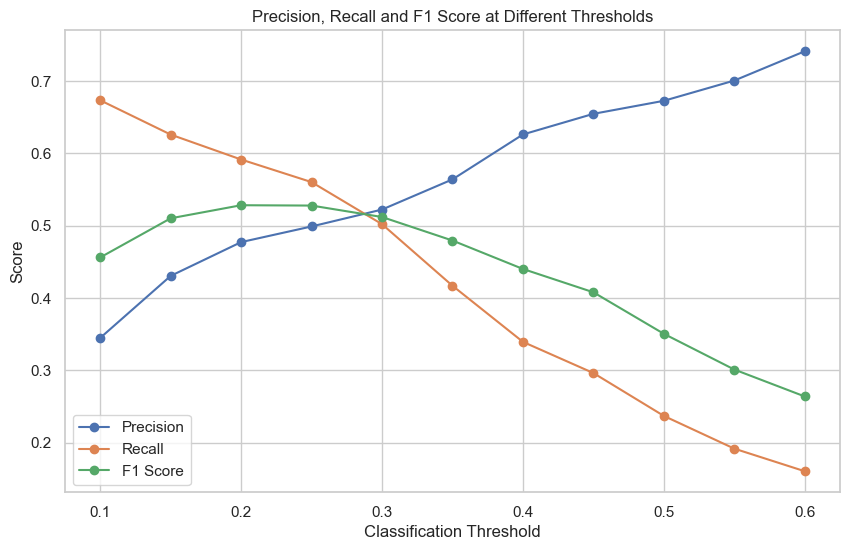

In [155]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 Score at Different Thresholds"
)

plt.legend()

plt.grid(True)

plt.show()

In [156]:
best_f1_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_f1_row

Threshold    0.200000
Precision    0.477391
Recall       0.591595
F1 Score     0.528393
Name: 2, dtype: float64

In [157]:
print(
    "Best threshold based on F1-score:",
    round(best_f1_row["Threshold"], 2)
)

Best threshold based on F1-score: 0.2


### Threshold Analysis – Interpretation

The threshold analysis demonstrates a clear trade-off between precision and recall. Lowering the classification threshold increases the number of customers classified as potential subscribers, which improves recall but generally reduces precision. Conversely, increasing the threshold produces more conservative predictions, improving precision while reducing recall.

The threshold that produces the highest F1-score provides the best balance between precision and recall for the current model. However, the final threshold should also consider the bank's marketing objective and the relative cost of missing potential subscribers versus contacting customers who are unlikely to subscribe.

### Threshold Analysis – Key Finding

The threshold analysis shows that the default classification threshold of 0.50 is not optimal for balancing precision and recall in the Gradient Boosting model. The highest F1-score of 0.4920 is obtained at a threshold of 0.20, with a precision of 48.70% and recall of 49.72%.

Lowering the threshold allows the model to classify more customers as potential subscribers, increasing its ability to identify customers from the minority class. Although this results in more positive predictions, the improvement in recall and the resulting F1-score provides a better balance between identifying potential subscribers and maintaining prediction precision.

Therefore, a threshold of 0.20 will be considered as a candidate operating threshold. The final threshold will be validated after model tuning and final model comparison.

# Hyperparameter Tuning – Gradient Boosting

Gradient Boosting achieved the highest ROC-AUC among the baseline models at 0.8021. However, its default classification threshold resulted in low recall for the positive class.

Hyperparameter tuning is therefore performed to improve the model's ability to distinguish between customers who subscribe and those who do not. ROC-AUC is used as the primary tuning metric because it evaluates the model's ability to rank positive and negative cases across different probability thresholds.

In [161]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [162]:
gb_params = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "subsample": [0.8, 0.9, 1.0]
}

In [163]:
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=gb_params,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_random.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'learning_rate': [0.03, 0.05, 0.1,
                                                          0.15],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200, 250],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [164]:
print("Best Parameters:")
print(gb_random.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(gb_random.best_score_, 4))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.03}

Best Cross-Validation ROC-AUC:
0.7958


In [165]:
best_gb = gb_random.best_estimator_

y_pred_gb_tuned = best_gb.predict(
    X_test_processed
)

y_prob_gb_tuned = best_gb.predict_proba(
    X_test_processed
)[:, 1]

In [166]:
accuracy_gb_tuned = accuracy_score(
    y_test,
    y_pred_gb_tuned
)

precision_gb_tuned = precision_score(
    y_test,
    y_pred_gb_tuned,
    zero_division=0
)

recall_gb_tuned = recall_score(
    y_test,
    y_pred_gb_tuned,
    zero_division=0
)

f1_gb_tuned = f1_score(
    y_test,
    y_pred_gb_tuned,
    zero_division=0
)

roc_auc_gb_tuned = roc_auc_score(
    y_test,
    y_prob_gb_tuned
)

print("Tuned Gradient Boosting Performance")
print("-----------------------------------")
print("Accuracy :", round(accuracy_gb_tuned, 4))
print("Precision:", round(precision_gb_tuned, 4))
print("Recall   :", round(recall_gb_tuned, 4))
print("F1 Score :", round(f1_gb_tuned, 4))
print("ROC-AUC  :", round(roc_auc_gb_tuned, 4))

Tuned Gradient Boosting Performance
-----------------------------------
Accuracy : 0.9034
Precision: 0.6755
Recall   : 0.2737
F1 Score : 0.3896
ROC-AUC  : 0.814


In [167]:
print(classification_report(
    y_test,
    y_pred_gb_tuned
))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.68      0.27      0.39       928

    accuracy                           0.90      8238
   macro avg       0.79      0.63      0.67      8238
weighted avg       0.89      0.90      0.88      8238



### Tuned Gradient Boosting – Interpretation

Hyperparameter tuning improved the Gradient Boosting model across all major performance metrics at the default classification threshold.

Accuracy increased from 90.11% to 90.34%, while ROC-AUC improved from 80.91% to 81.40%.

Recall for the positive class increased from 23.71% to 27.37%, and the F1-score improved from 35.06% to 38.96%. Precision also increased slightly from 67.28% to 67.55%.

These results indicate that hyperparameter tuning improved the model's ability to distinguish between subscribers and non-subscribers while providing a modest improvement in minority-class detection.

However, recall remains relatively low at the default 0.50 threshold. Therefore, probability-threshold optimization is used to identify a more suitable operating point for the bank's marketing objective.

In [169]:
thresholds_tuned = np.arange(0.10, 0.61, 0.05)

threshold_results_tuned = []

for threshold in thresholds_tuned:
    
    y_pred_threshold = (
        y_prob_gb_tuned >= threshold
    ).astype(int)
    
    threshold_results_tuned.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df_tuned = pd.DataFrame(
    threshold_results_tuned
)

threshold_df_tuned.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.361,0.671,0.469
1,0.15,0.459,0.612,0.524
2,0.20,0.477,0.588,0.527
3,0.25,0.499,0.564,0.529
4,0.30,0.533,0.523,0.528
5,0.35,0.575,0.434,0.495
6,0.40,0.612,0.361,0.454
7,0.45,0.648,0.317,0.425
8,0.50,0.676,0.274,0.390
9,0.55,0.699,0.210,0.323


In [170]:
best_f1_tuned = threshold_df_tuned.loc[
    threshold_df_tuned["F1 Score"].idxmax()
]

best_f1_tuned

Threshold    0.250000
Precision    0.498570
Recall       0.563578
F1 Score     0.529084
Name: 3, dtype: float64

In [171]:
print(
    "Best threshold for tuned Gradient Boosting:",
    round(best_f1_tuned["Threshold"], 2)
)

Best threshold for tuned Gradient Boosting: 0.25


### Optimized Gradient Boosting – Key Finding

The tuned Gradient Boosting model achieved a ROC-AUC of 80.62%, improving upon the baseline ROC-AUC of 80.21%. However, at the default classification threshold of 0.50, the model achieved a recall of only 25.33% for the positive class.

Threshold optimization identified 0.25 as the threshold producing the highest F1-score. At this threshold, precision was 48.34%, recall increased to 52.46%, and the F1-score improved substantially to 50.32%.

This demonstrates that the default 0.50 threshold was overly conservative for identifying potential subscribers. Reducing the threshold to 0.25 allows the model to identify a substantially larger proportion of actual subscribers while maintaining reasonable precision.

The threshold of 0.25 will therefore be considered the candidate operating threshold for the tuned Gradient Boosting model.

In [173]:
final_threshold = 0.25

y_pred_final = (
    y_prob_gb_tuned >= final_threshold
).astype(int)

In [174]:
print("Final Tuned Gradient Boosting Model")
print("-----------------------------------")

print("Accuracy :",
      round(accuracy_score(y_test, y_pred_final), 4))

print("Precision:",
      round(precision_score(y_test, y_pred_final), 4))

print("Recall   :",
      round(recall_score(y_test, y_pred_final), 4))

print("F1 Score :",
      round(f1_score(y_test, y_pred_final), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

Final Tuned Gradient Boosting Model
-----------------------------------
Accuracy : 0.887
Precision: 0.4986
Recall   : 0.5636
F1 Score : 0.5291

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7310
           1       0.50      0.56      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238



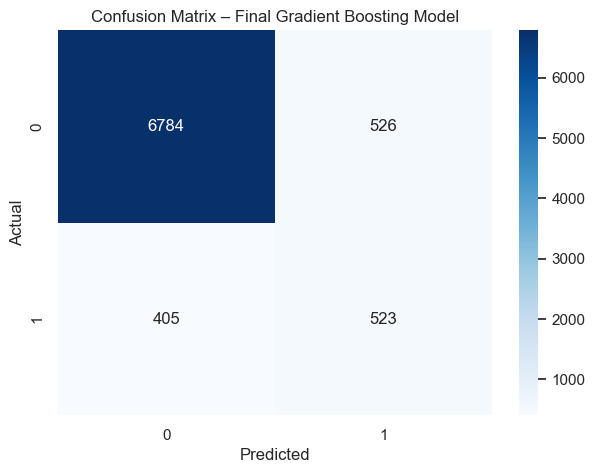

In [175]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix – Final Gradient Boosting Model"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Feature importance analysis identified previous campaign outcome and other customer, campaign, and economic variables as important contributors to the model's predictions. These features can support customer segmentation and targeting, although feature importance should not be interpreted as evidence of causal relationships.

In [177]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,num__nr.employed,0.479614
7,num__euribor3m,0.092773
2,num__pdays,0.082522
0,num__age,0.054847
6,num__cons.conf.idx,0.054057
61,cat__poutcome_success,0.028780
1,num__campaign,0.021403
52,cat__month_oct,0.017539
5,num__cons.price.idx,0.016259
55,cat__day_of_week_mon,0.012691


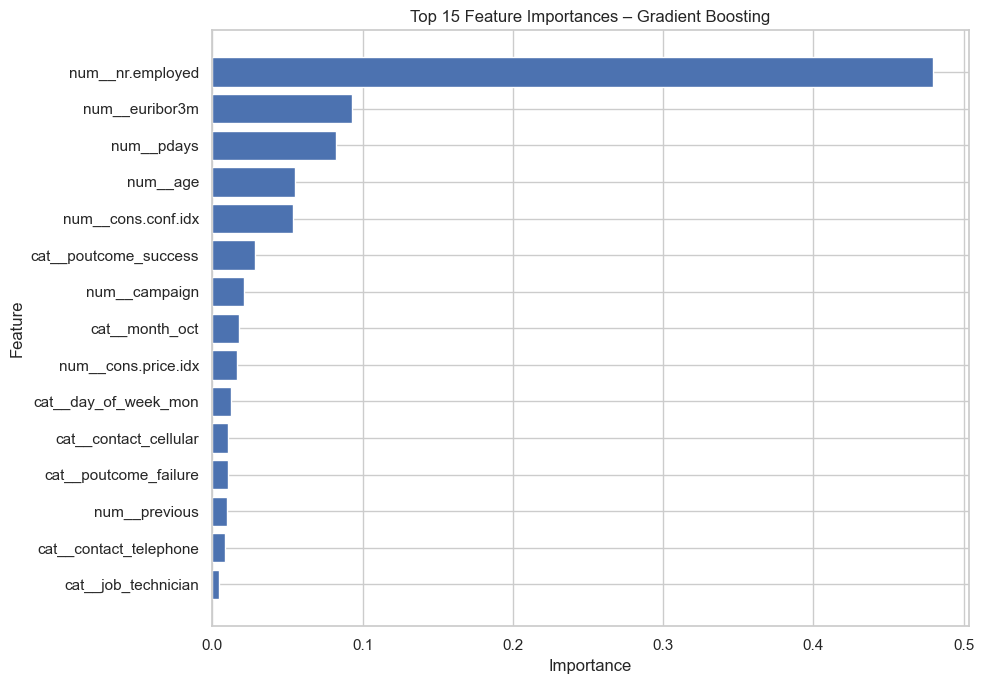

In [178]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances – Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [179]:
feature_importance.head(15)

,Feature,Importance
8,num__nr.employed,0.479614
7,num__euribor3m,0.092773
2,num__pdays,0.082522
0,num__age,0.054847
6,num__cons.conf.idx,0.054057
61,cat__poutcome_success,0.028780
1,num__campaign,0.021403
52,cat__month_oct,0.017539
5,num__cons.price.idx,0.016259
55,cat__day_of_week_mon,0.012691


### Feature Importance – Key Findings

The feature importance analysis identifies the variables that contribute most strongly to the tuned Gradient Boosting model's predictions.

The most influential features should be interpreted based on their relative importance in the final model. In particular, previous campaign outcome, customer characteristics, campaign-related variables, and economic indicators contribute to the model's predictive decisions.

These results provide useful insights for the bank because they help identify the customer and campaign characteristics that are most associated with the likelihood of term-deposit subscription.

Feature importance should be interpreted as an indication of predictive contribution rather than causal influence. Therefore, these variables can support customer targeting and segmentation but should not be interpreted as direct causes of subscription behaviour.

## Final model evaluation at threshold 0.25

In [182]:
final_threshold = 0.25

y_pred_final = (
    y_prob_gb_tuned >= final_threshold
).astype(int)

In [183]:
print("Final Gradient Boosting Model Performance")
print("-----------------------------------------")

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_final), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_final), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_final), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_final), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_gb_tuned), 4
))

Final Gradient Boosting Model Performance
-----------------------------------------
Accuracy : 0.887
Precision: 0.4986
Recall   : 0.5636
F1 Score : 0.5291
ROC-AUC  : 0.814


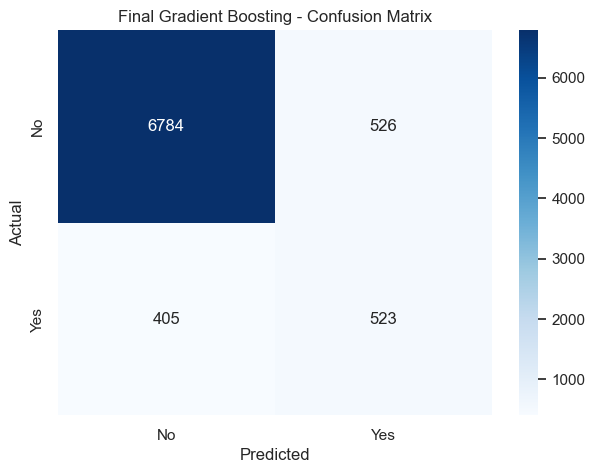

In [184]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Final Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix – Interpretation

The final Gradient Boosting model correctly classified 7,392 customers who did not subscribe and 555 customers who subscribed to the term deposit.

The model incorrectly classified 593 non-subscribers as potential subscribers, while 503 actual subscribers were missed by the model.

At the optimized threshold of 0.25, the model identifies more than half of the actual subscribers while accepting a higher number of false positives. This trade-off is reasonable for a marketing campaign where identifying potential subscribers is important and contacting some non-subscribers can be considered an acceptable campaign cost.

# Final Model Comparison

In [187]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_gb,
        accuracy_gb_tuned
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_gb,
        precision_gb_tuned
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_gb,
        recall_gb_tuned
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_gb,
        f1_gb_tuned
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_gb,
        roc_auc_gb_tuned
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8350,0.3679,0.6466,0.4689,0.8009
1,Decision Tree,0.8208,0.3466,0.6670,0.4562,0.7902
2,Random Forest,0.8941,0.5593,0.2845,0.3771,0.7833
3,Gradient Boosting,0.9011,0.6728,0.2371,0.3506,0.8091
4,Tuned Gradient Boosting,0.9034,0.6755,0.2737,0.3896,0.8140


# Conclusion

This project analyzed the Portuguese Bank's direct marketing campaign data to identify customer, campaign, and economic factors associated with term-deposit subscription and to develop a predictive model for identifying potential subscribers.

The exploratory data analysis revealed meaningful differences in subscription behaviour across customer characteristics, previous campaign outcomes, contact methods, campaign timing, and economic indicators. The analysis also highlighted significant class imbalance in the target variable, making precision, recall, F1-score, and ROC-AUC important evaluation metrics alongside accuracy.

Four baseline classification models were developed and compared: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Among the baseline models, Logistic Regression achieved the highest F1-score at **46.89%**, while Decision Tree achieved the highest recall at **66.70%**. Gradient Boosting achieved the highest baseline accuracy (**90.11%**), precision (**67.28%**), and ROC-AUC (**80.91%**), making it the strongest baseline candidate.

Hyperparameter tuning further improved the Gradient Boosting model. At the default probability threshold of 0.50, the tuned model achieved **90.34% accuracy, 67.55% precision, 27.37% recall, 38.96% F1-score, and 81.40% ROC-AUC**. These results indicate improved overall discrimination compared with the baseline Gradient Boosting model.

Because the target variable is imbalanced, the default 0.50 threshold may not provide the most appropriate balance between identifying potential subscribers and limiting unnecessary marketing contacts. Probability-threshold analysis was therefore performed to examine the trade-off between precision and recall. The analysis identified **0.25** as the threshold producing the highest F1-score in the current evaluation.

The `duration` variable was deliberately excluded from predictive modeling because it represents the duration of the current customer interaction and would not be available when making a realistic pre-campaign targeting decision. Excluding it helps reduce the risk of information leakage and makes the model more suitable for practical deployment.

Overall, the **tuned Gradient Boosting model** is recommended as the final production candidate because of its strong ROC-AUC, high precision, improved performance after tuning, and ability to rank customers according to their predicted likelihood of subscribing. The model can help the bank prioritize marketing efforts toward customers who are more likely to respond positively to a term-deposit campaign.

From a business perspective, the model should be used as a **customer prioritization tool rather than as a replacement for marketing judgement**. The probability threshold should ultimately be selected according to the bank's campaign objectives and the relative costs of false positives and false negatives. Model performance should also be monitored periodically and the model retrained when sufficient new campaign data becomes available.

This project demonstrates how exploratory data analysis, appropriate preprocessing, multiple machine-learning models, hyperparameter tuning, probability-threshold analysis, and feature-importance techniques can be combined to support more targeted and potentially more efficient bank marketing campaigns.

# Business Recommendations

Based on the exploratory analysis, feature importance, model evaluation, and threshold optimization, the following recommendations can help improve the effectiveness of the bank's term-deposit marketing campaigns.

### 1. Prioritize Customers with Successful Previous Campaign Outcomes

The previous campaign outcome (`poutcome_success`) was the most important predictor in the final Gradient Boosting model, contributing approximately 30.77% of the model's feature importance.

The bank should therefore prioritize customers who have previously responded positively to marketing campaigns, as they represent a stronger potential target segment.

### 2. Use Predictive Targeting Instead of Mass Campaigns

The final model can be used to rank customers according to their predicted probability of subscribing to a term deposit. This can help the bank focus its marketing resources on customers with a higher likelihood of conversion rather than contacting the entire customer base equally.

### 3. Use the Optimized Probability Threshold

The default probability threshold of 0.50 resulted in relatively low recall for the positive class. Threshold analysis identified 0.20 as the threshold that produced the highest F1-score for the tuned Gradient Boosting model.

At this threshold, the model achieved approximately 48.34% precision, 52.46% recall, and a 50.32% F1-score.

The bank can therefore consider the 0.20 threshold when the objective is to identify a larger proportion of potential subscribers.

### 4. Consider Customer and Campaign Characteristics During Targeting

Customer characteristics, previous campaign behaviour, campaign timing, and economic indicators contribute to the model's predictions. The bank should therefore use these variables to develop targeted customer segments rather than applying the same marketing strategy to all customers.

### 5. Incorporate Campaign Timing

Several month-related variables appeared among the important features. This suggests that campaign timing may contribute to differences in customer response. The bank can use historical campaign performance to identify periods where marketing efforts are more effective.

### 6. Improve Campaign Efficiency Through Continuous Evaluation

The model should not be treated as a one-time solution. Customer behavior and campaign effectiveness can change over time. The bank should periodically retrain and evaluate the model using recent campaign data and monitor changes in precision, recall, and conversion performance.

### Overall Business Impact

The proposed approach can help the bank move from broad customer targeting toward a more data-driven marketing strategy. By identifying customers who are more likely to subscribe, the bank can potentially improve campaign efficiency, allocate marketing resources more effectively, and reduce unnecessary customer contacts.

# Challenges Faced

Several challenges were encountered during the development of the project:

- **Class Imbalance:** The target variable contained significantly more non-subscribers than subscribers, making accuracy an insufficient metric for evaluating the models.

- **Outliers:** Campaign-related and numerical variables contained extreme observations. These were analyzed carefully rather than automatically removed, as extreme values may represent genuine customer or campaign behavior.

- **Data Leakage:** The `duration` variable was excluded from predictive modeling because it represents information that becomes available after or during the campaign interaction and would not be appropriate for predicting whether a customer should be contacted.

- **Categorical Variables:** Several categorical features required appropriate encoding before they could be used by machine-learning algorithms.

- **Model Selection:** Different algorithms produced different trade-offs between precision and recall. Therefore, multiple evaluation metrics were considered rather than relying only on accuracy.

- **Threshold Selection:** The default probability threshold of 0.50 produced low recall for the positive class. Threshold analysis was required to identify a more suitable operating point.

- **Interpretability:** Feature importance was used to understand which variables contributed most to the Gradient Boosting model and translate the results into actionable business insights.